Dataset: n=891, p_surv=0.3838
Pclass1: N=216, K_surv=136 (63.0%)

=== BINOMIAL Bin(n=10, p=0.3838) ===
P(X=4): 0.2494
P(X>=4): 0.5764

=== POISSON (Pclass1 deaths, λ=8.0 per 10) ===
P(X=2): 0.0107

=== HYPERGEOMETRIC (Pclass1: N=216,K=136,n=25) ===
P(X=18): 0.1109


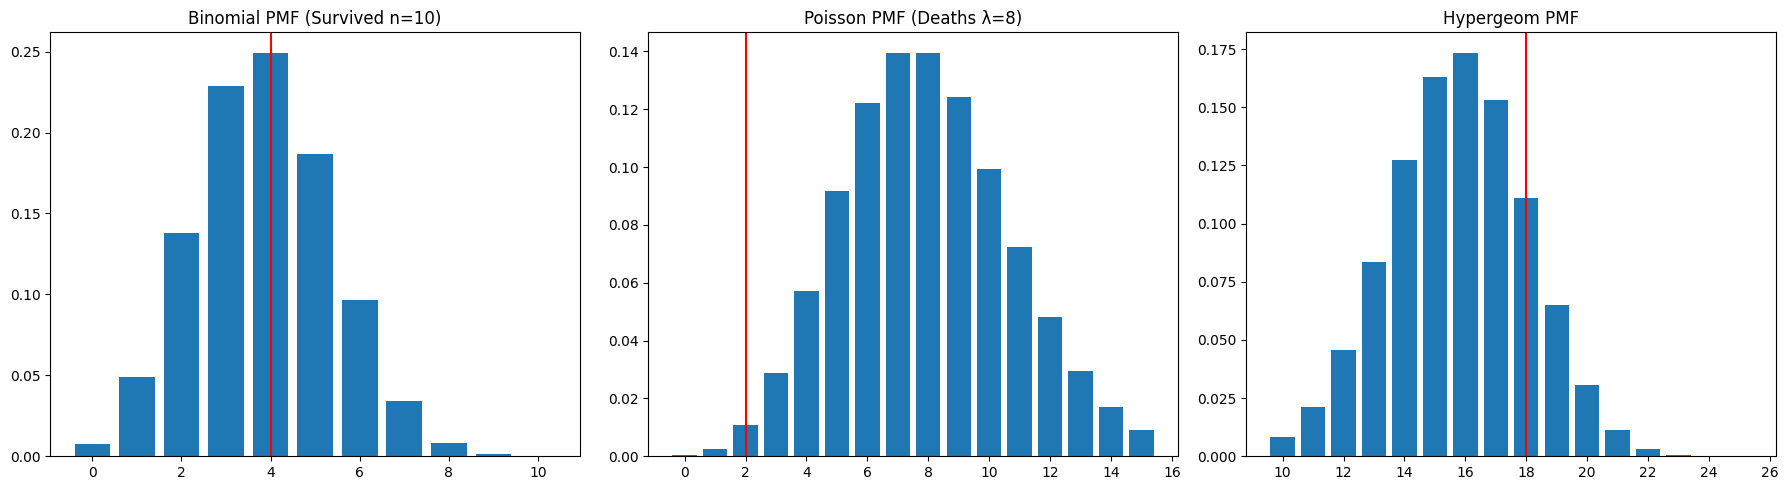

In [11]:
# Data Science Lab Assignment 5: Discrete Probability Distributions
# Dataset: Titanic (Kaggle UCI) [web:21]

import pandas as pd
import numpy as np
from scipy.stats import binom, poisson, hypergeom
import matplotlib.pyplot as plt
import seaborn as sns

# Load & stats
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
n_total = len(df)  # 891
p_surv = df['Survived'].mean()  # 0.3838
pclass1 = df[df['Pclass']==1]
N1, K1 = len(pclass1), pclass1['Survived'].sum()  # 216, 136

print("Dataset: n=891, p_surv=%.4f" % p_surv)
print("Pclass1: N=%d, K_surv=%d (%.1f%%)" % (N1, K1, K1/N1*100))

# 1. BINOMIAL: Survival in n=10 random passengers
n_bin = 10
k_bin = 4
pmf_bin = binom.pmf(k_bin, n_bin, p_surv)
cdf_bin_ge4 = 1 - binom.cdf(3, n_bin, p_surv)
print("\n=== BINOMIAL Bin(n=10, p=0.3838) ===")
print("P(X=%d): %.4f" % (k_bin, pmf_bin))
print("P(X>=4): %.4f" % cdf_bin_ge4)

# 2. POISSON: Rare deaths Pclass1 (80 deaths/216 ~ λ=8 per 10 groups)
lambda_poi = 80 / 21.6  # ~3.7 per group, scale to 10: 8
k_poi = 2
pmf_poi = poisson.pmf(k_poi, lambda_poi*10/10)  # λ=8 for 10 units
print("\n=== POISSON (Pclass1 deaths, λ=8.0 per 10) ===")
print("P(X=%d): %.4f" % (k_poi, poisson.pmf(k_poi, 8.0)))

# 3. HYPERGEOMETRIC: Draw n=25 from Pclass1, survived k=18
n_hyper, k_hyper = 25, 18
pmf_hyper = hypergeom.pmf(k_hyper, N1, K1, n_hyper)
print("\n=== HYPERGEOMETRIC (Pclass1: N=216,K=136,n=25) ===")
print("P(X=%d): %.4f" % (k_hyper, pmf_hyper))

# VISUALIZATIONS
fig, axes = plt.subplots(1,3, figsize=(18,5))

# Binomial PMF
x_bin = np.arange(0,11)
axes[0].bar(x_bin, binom.pmf(x_bin, n_bin, p_surv))
axes[0].axvline(k_bin, color='r', label='k=4')
axes[0].set_title('Binomial PMF (Survived n=10)')

# Poisson
x_poi = np.arange(0,16)
axes[1].bar(x_poi, poisson.pmf(x_poi, 8))
axes[1].axvline(2, color='r', label='k=2')
axes[1].set_title('Poisson PMF (Deaths λ=8)')

# Hypergeom
x_hyper = np.arange(10,26)
axes[2].bar(x_hyper, hypergeom.pmf(x_hyper, N1, K1, n_hyper))
axes[2].axvline(18, color='r', label='k=18')
axes[2].set_title('Hypergeom PMF')

plt.tight_layout()
plt.show()
